
Feature_Engineering.ipynb
==============================
Feature selection and data preparation for model training.

Steps covered:
- Loaded cleaned freight dataset
- Analyzed feature correlations via heatmap and Random Forest importance
- Dropped low importance features (lat/lon, date parts, equipment columns)
- Applied time-based split (Train: Jan-Aug 2025 | Test: Sep-Oct 2025)
  to prevent future data leakage into training
- Scaled features using StandardScaler fitted on train only

Output:
- train_data.csv
- test_data.csv


#  import libraries

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# load dataset

In [30]:

df = pd.read_csv('../dataset/processed/cleaned_freight_data.csv')
print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (47408, 16)
['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'posted_rate', 'month', 'day_of_week', 'quarter', 'is_weekend', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']


,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,weight,market_index,quote_signal,posted_rate,month,day_of_week,quarter,is_weekend,equip_Dry Van,equip_Flatbed,equip_Reefer
0,38.09122,-76.78906,38.16908,-72.74564,274.3,30658.0,0.95684,2.39595,645.41,1,2,1,0,True,False,False
1,38.09122,-76.78906,39.22317,-72.96710,280.5,17555.0,0.97623,2.43355,679.97,1,2,1,0,False,False,True
2,39.22317,-72.96710,44.30296,-87.52871,967.8,31721.0,1.00971,1.84491,1802.54,1,2,1,0,True,False,False
3,39.55328,-72.18051,34.84933,-86.28940,965.4,32333.0,0.94518,1.87712,1827.28,1,2,1,0,True,False,False
4,31.83025,-94.38343,35.29479,-88.08915,541.9,35183.0,0.98480,2.56300,1380.28,1,2,1,0,False,False,True


# correlation heatmap all numuric


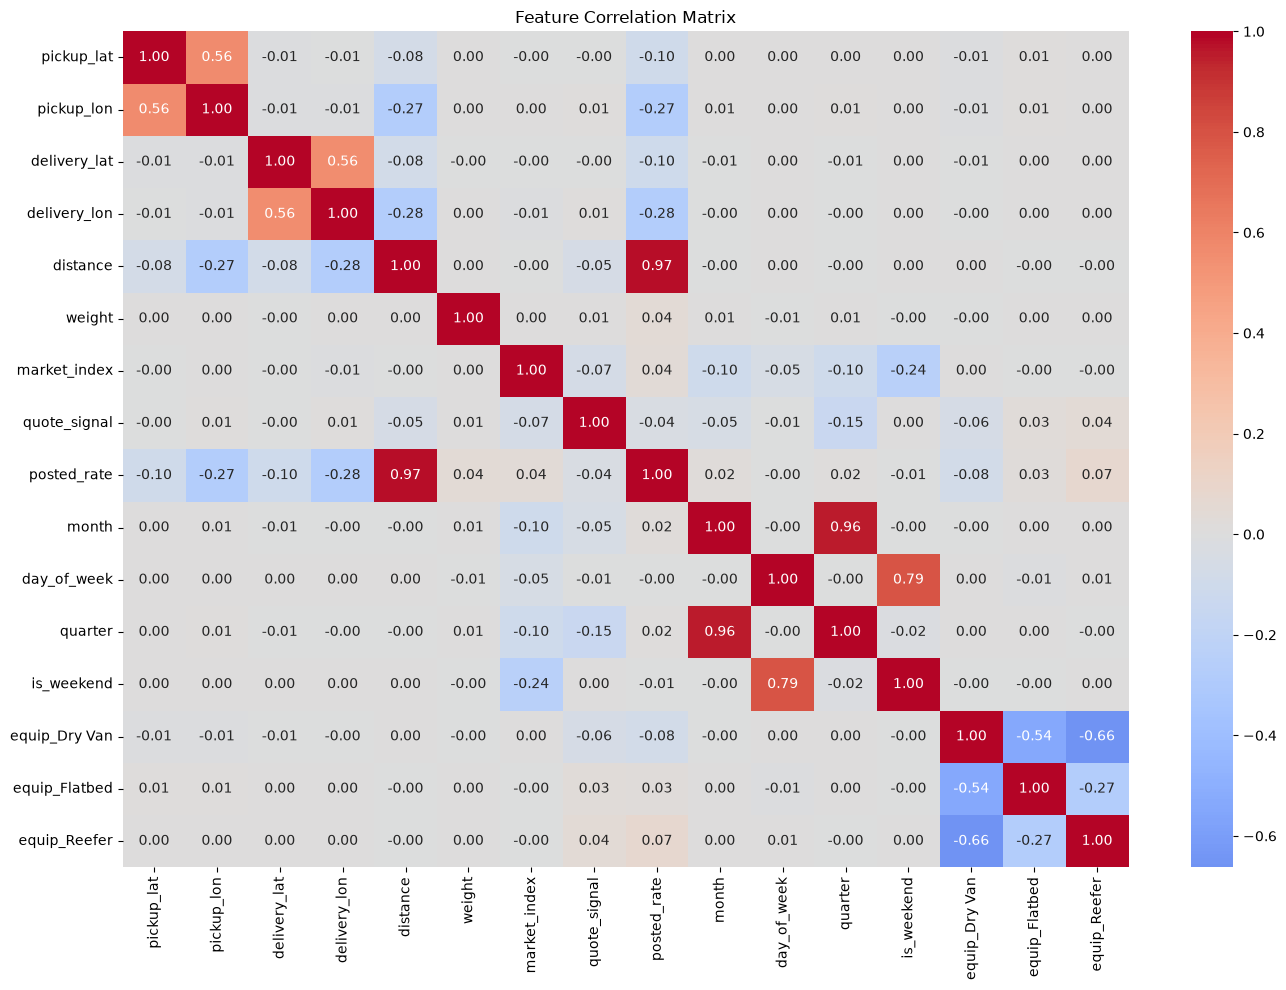

In [31]:
plt.figure(figsize=(14, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

distance         0.974716
equip_Reefer     0.073569
weight           0.044417
market_index     0.035529
equip_Flatbed    0.025177
month            0.021716
quarter          0.015627
day_of_week     -0.001191
is_weekend      -0.006501
quote_signal    -0.038354
equip_Dry Van   -0.083995
pickup_lat      -0.095645
delivery_lat    -0.098792
pickup_lon      -0.273483
delivery_lon    -0.278349
Name: posted_rate, dtype: float64


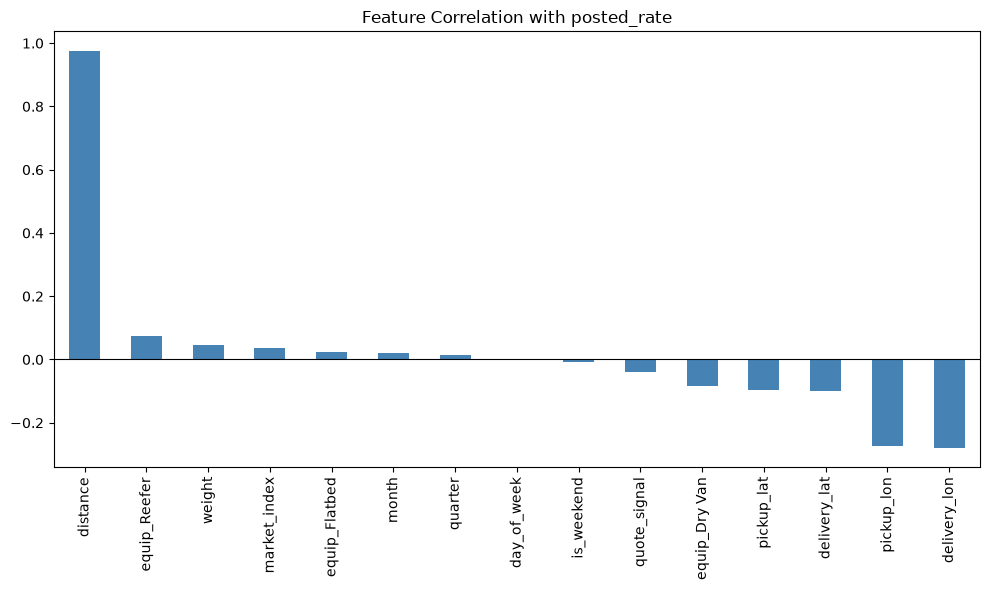

In [32]:
corr_target = df.corr()['posted_rate'].drop('posted_rate').sort_values(ascending=False)
print(corr_target)

plt.figure(figsize=(10, 6))
corr_target.plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with posted_rate')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# chi-square test for encoded categorical columns

In [33]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import MinMaxScaler

# chi2 requires non-negative values
cat_cols = [c for c in df.columns if 'equip' in c]
X_cat = df[cat_cols]
y = df['posted_rate']

chi_scores, p_values = chi2(X_cat, y.astype(int))
chi_df = pd.DataFrame({'feature': cat_cols, 'chi2_score': chi_scores, 'p_value': p_values})
print(chi_df.sort_values('chi2_score', ascending=False))

         feature   chi2_score  p_value
1  equip_Flatbed  5044.179932      1.0
2   equip_Reefer  4936.660645      1.0
0  equip_Dry Van  2827.707737      1.0


# Feature importance via Random Forest

          feature  importance
4        distance    0.958248
12  equip_Dry Van    0.009696
7    quote_signal    0.009545
5          weight    0.005777
6    market_index    0.004876
3    delivery_lon    0.002263
2    delivery_lat    0.001936
8           month    0.001811
0      pickup_lat    0.001796
1      pickup_lon    0.001699
9     day_of_week    0.001001
10        quarter    0.000532
14   equip_Reefer    0.000313
13  equip_Flatbed    0.000293
11     is_weekend    0.000214


C:\Users\LAKSHAN\AppData\Local\Temp\ipykernel_1380\605811431.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


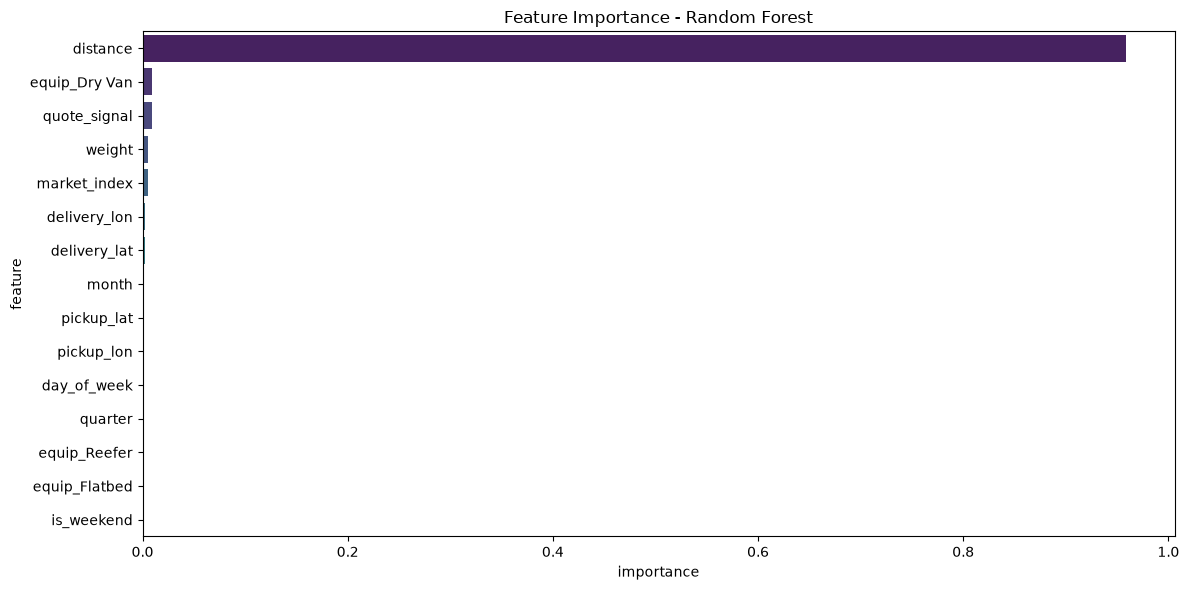

In [34]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['posted_rate'])
y = df['posted_rate']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

# Drop low importance featuers

In [35]:
drop_cols = [
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'month', 'day_of_week', 'quarter', 'is_weekend'
]

df_selected = df.drop(columns=drop_cols)
print("Final features:", df_selected.columns.tolist())
print("Shape:", df_selected.shape)

Final features: ['distance', 'weight', 'market_index', 'quote_signal', 'posted_rate', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']
Shape: (47408, 8)


In [36]:
df_selected.head()

,distance,weight,market_index,quote_signal,posted_rate,equip_Dry Van,equip_Flatbed,equip_Reefer
0,274.3,30658.0,0.95684,2.39595,645.41,True,False,False
1,280.5,17555.0,0.97623,2.43355,679.97,False,False,True
2,967.8,31721.0,1.00971,1.84491,1802.54,True,False,False
3,965.4,32333.0,0.94518,1.87712,1827.28,True,False,False
4,541.9,35183.0,0.98480,2.56300,1380.28,False,False,True


# Prepare dataset for Training

In [37]:
#reload cleaned_frieght_data.csv to get the date column back
df_raw = pd.read_csv('../dataset/processed/cleaned_freight_data.csv')

- Time-based split instead of random split
- Freight rates are time-dependent  random split would leak future market conditions
- into training, causing inflated performance that fails in real world.
- Train on past (Jan-Aug), predict future (Sep-Oct) mirrors real deployment.
- split_date = '2025-09-01'

In [38]:
# Time-based split using month column since date was extracted in EDA
# Train: Jan-Aug (month 1-8), Test: Sep-Oct (month 9-10)
train_df = df[df['month'] <= 8]
test_df  = df[df['month'] > 8]

print("Train:", train_df.shape, "| Months:", train_df['month'].min(), "→", train_df['month'].max())
print("Test: ", test_df.shape,  "| Months:", test_df['month'].min(), "→", test_df['month'].max())
print(f"\nTrain %: {len(train_df)/len(df)*100:.1f}%")
print(f"Test  %: {len(test_df)/len(df)*100:.1f}%")

Train: (38009, 16) | Months: 1 → 8
Test:  (9399, 16) | Months: 9 → 10

Train %: 80.2%
Test  %: 19.8%


In [39]:
# Apply selected features on split
selected_features = ['distance', 'quote_signal', 'weight', 'market_index', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']
target = 'posted_rate'

X_train = train_df[selected_features]
y_train = train_df[target]

X_test = test_df[selected_features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

X_train: (38009, 7)
X_test:  (9399, 7)


In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("Scaling done ")

Scaling done 


In [41]:
import joblib

# Save scaler for future real world predictions
joblib.dump(scaler, '../weights/scaler.pkl')
print("Saved scaler.pkl")

# Save scaled arrays as dataframes with feature names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=selected_features)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=selected_features)

# Add target back
X_train_scaled_df['posted_rate'] = y_train.values
X_test_scaled_df['posted_rate']  = y_test.values

X_train_scaled_df.to_csv('../dataset/processed/train_scaled.csv', index=False)
X_test_scaled_df.to_csv('../dataset/processed/test_scaled.csv',   index=False)

print("Saved train_scaled.csv:", X_train_scaled_df.shape)
print("Saved test_scaled.csv: ", X_test_scaled_df.shape)

Saved scaler.pkl
Saved train_scaled.csv: (38009, 8)
Saved test_scaled.csv:  (9399, 8)
